# Exploring Huge100K batch 1

This notebook is a tutorial-style walkthrough for the Huge100K batch 1 dataset. The goal is to help you understand how the files are organized, how to find a specific sample, and what the parameter files and media assets represent.

## Dataset structure at a glance

The dataset is not organized as one folder per subject like a mesh dataset. Instead, it is grouped by image-batch folders such as `images0`, `images1`, and so on. Each of those folders contains:

- a `param/` directory with `.npy` parameter files
- a `videos/` directory with paired `.jpg` and `.mp4` files

In [1]:
from pathlib import Path
import numpy as np

# Try a few likely locations so the notebook works whether it is launched from the repo root
# or from the Notebooks folder.
candidate_roots = [Path.cwd(), Path.cwd().parent]
DATASET_ROOT = None

for root in candidate_roots:
    candidate = root / "Datasets" / "Huge100K" / "batch 1"
    if candidate.exists():
        DATASET_ROOT = candidate
        break

if DATASET_ROOT is None:
    raise FileNotFoundError("Could not find the Huge100K dataset. Check the workspace path.")

DATASET_ROOT

PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1')

In [2]:
# The dataset is divided into image-group folders such as images0, images1, ...
image_groups = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir() and p.name.startswith("images")])
image_groups[:5]

[PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0'),
 PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images1'),
 PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images2'),
 PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images3'),
 PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images4')]

In [3]:
# Count how many sample files exist in each group.
# The `param/` folder contains parameter arrays and the `videos/` folder contains media files.
for group in image_groups:
    param_dir = group / "param"
    video_dir = group / "videos"
    param_files = sorted(param_dir.glob("*.npy")) if param_dir.exists() else []
    video_files = sorted(video_dir.glob("*")) if video_dir.exists() else []
    print(f"{group.name}: {len(param_files)} param files, {len(video_files)} media files")

images0: 759 param files, 1518 media files
images1: 713 param files, 1426 media files
images2: 693 param files, 1386 media files
images3: 657 param files, 1314 media files
images4: 734 param files, 1468 media files
images5: 726 param files, 1452 media files
images6: 735 param files, 1470 media files
images7: 711 param files, 1422 media files


## Inspecting one sample

The filenames often encode the subject attributes in a human-readable way, such as country, body type, clothing, age range, and an ID. That makes it possible to browsed the dataset even before opening the arrays.

In [4]:
# Pick one representative group and inspect its files.
sample_group = image_groups[0]
sample_param_dir = sample_group / "param"
sample_video_dir = sample_group / "videos"

sample_param_files = sorted(sample_param_dir.glob("*.npy"))
sample_video_files = sorted(sample_video_dir.glob("*.jpg"))

sample_param_files[:5], sample_video_files[:5]

([PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/param/Algeria_female_buff_blazers_40~50 years old_279.npy'),
  PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/param/Algeria_female_petite_diplomatic suits_20~30 years old_475.npy'),
  PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/param/Algeria_male_average_sweaters_20~30 years old_1087.npy'),
  PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/param/Algeria_male_average_thick cotton sweaters_60~70 years old_874.npy'),
  PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/param/Algeria_male_full-figured_avant-garde designs_30~40 years old_618.npy')],
 [PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/videos/Algeria_female_buff_blazers_40~50 years old_279.jpg'),
  PosixPath('/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1/images0/videos/Algeria_female_petite_diplomatic suits_20~30 years old_475.jpg'),
  PosixP

In [5]:
# Load one parameter file.
# Many of these `.npy` files are serialized objects rather than plain numeric arrays,
# so this may require a specific dependency such as PyTorch to deserialize.
sample_param_path = sample_param_files[0]

try:
    data = np.load(sample_param_path, allow_pickle=True)
    print(type(data))
    print("shape:", getattr(data, "shape", None))
    print("dtype:", getattr(data, "dtype", None))
    print("preview:", data)
except ModuleNotFoundError as exc:
    print("This parameter file could not be loaded in the current environment:")
    print(exc)
    print("That usually means the file contains a pickled object that depends on a package such as torch.")

<class 'numpy.ndarray'>
shape: ()
dtype: object
preview: {'smpl_params': tensor([ 1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00, -2.1994e-02, -6.3626e-03,  9.0689e-02,
         4.3315e-03,  2.7527e-03, -9.6273e-02,  2.8825e-02, -5.0868e-02,
        -2.7887e-02,  1.8294e-02, -1.3733e-02,  1.6440e-02, -2.2484e-02,
        -1.0907e-02, -4.1117e-03, -6.1065e-03,  4.9500e-02,  3.2797e-02,
        -1.3741e-02,  3.0372e-02,  6.8676e-03,  1.9976e-02,  5.8449e-03,
        -1.8954e-02, -2.2726e-02,  1.8608e-02,  1.0668e-02,  8.5378e-02,
        -9.1540e-02, -7.5316e-02,  2.2139e-02,  4.3389e-02,  5.0328e-02,
        -2.1722e-02, -1.4290e-02, -4.1900e-02,  6.0863e-02,  2.2843e-03,
         9.1820e-02,  9.0270e-02, -5.9793e-02, -1.3657e-01,  6.6757e-02,
        -1.1788e-02,  2.7897e-02, -8.5466e-02, -4.3662e-02, -7.1011e-01,
        -8.0521e-02,  8.1132e-02,  7.2304e-01, -3.0473e-03,  5.2156e-02,
        -1.6481e-01,  6.1413e-03, -3.9547e-02,  1.7

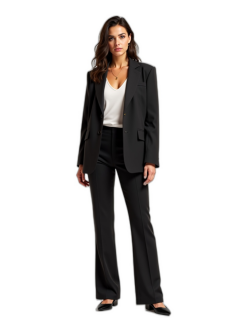

In [6]:
# Visualize one of the image assets from the same sample group.
from PIL import Image
from matplotlib import pyplot as plt

image_path = sample_video_files[0]
image = Image.open(image_path)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(image)
ax.axis("off")
plt.show()

## Explore parameter, image, and video files

The next cells summarize the batch and show one concrete example of how the parameter files, images, and videos line up.

In [7]:
from pathlib import Path

root = Path("/Users/leeon/AvatarVerse/Datasets/Huge100K/batch 1")
image_groups = sorted([p for p in root.iterdir() if p.is_dir() and p.name.startswith("images")])

summary = []
for group in image_groups:
    param_dir = group / "param"
    video_dir = group / "videos"

    param_files = sorted([p for p in param_dir.glob("*.npy")]) if param_dir.exists() else []
    jpg_files = sorted([p for p in video_dir.glob("*.jpg")]) if video_dir.exists() else []
    mp4_files = sorted([p for p in video_dir.glob("*.mp4")]) if video_dir.exists() else []

    summary.append({
        "group": group.name,
        "params": len(param_files),
        "jpg": len(jpg_files),
        "mp4": len(mp4_files),
        "sample_param": param_files[0].name if param_files else None,
        "sample_image": jpg_files[0].name if jpg_files else None,
        "sample_video": mp4_files[0].name if mp4_files else None,
    })

print("Total groups:", len(summary))
print("Total params:", sum(item["params"] for item in summary))
print("Total jpg:", sum(item["jpg"] for item in summary))
print("Total mp4:", sum(item["mp4"] for item in summary))

for item in summary[:3]:
    print(item)


Total groups: 8
Total params: 5728
Total jpg: 5728
Total mp4: 5728
{'group': 'images0', 'params': 759, 'jpg': 759, 'mp4': 759, 'sample_param': 'Algeria_female_buff_blazers_40~50 years old_279.npy', 'sample_image': 'Algeria_female_buff_blazers_40~50 years old_279.jpg', 'sample_video': 'Algeria_female_buff_blazers_40~50 years old_279.mp4'}
{'group': 'images1', 'params': 713, 'jpg': 713, 'mp4': 713, 'sample_param': 'Algeria_female_buff_avant-garde designs_20~30 years old_544.npy', 'sample_image': 'Algeria_female_buff_avant-garde designs_20~30 years old_544.jpg', 'sample_video': 'Algeria_female_buff_avant-garde designs_20~30 years old_544.mp4'}
{'group': 'images2', 'params': 693, 'jpg': 693, 'mp4': 693, 'sample_param': 'Algeria_female_built_moroccan kaftans_90~100 years old_1070.npy', 'sample_image': 'Algeria_female_built_moroccan kaftans_90~100 years old_1070.jpg', 'sample_video': 'Algeria_female_built_moroccan kaftans_90~100 years old_1070.mp4'}


In [8]:
import numpy as np

sample_param_path = sample_param_files[0]
sample_image_path = sample_video_files[0]
sample_video_path = sample_group / "videos" / sample_image_path.name.replace(".jpg", ".mp4")

print("Parameter file:", sample_param_path.name)
print("Image file:", sample_image_path.name)
print("Video file:", sample_video_path.name)

print("\nAttempt 1: plain array load")
try:
    arr = np.load(sample_param_path, allow_pickle=False)
    print("Loaded successfully as a plain array")
    print("type:", type(arr))
    print("shape:", getattr(arr, "shape", None))
    print("dtype:", getattr(arr, "dtype", None))
except Exception as exc:
    print("plain-array load failed:", type(exc).__name__, exc)

print("\nAttempt 2: pickle-enabled load")
try:
    arr = np.load(sample_param_path, allow_pickle=True)
    print("Loaded successfully with pickle support")
    print("type:", type(arr))
except Exception as exc:
    print("pickle-enabled load failed:", type(exc).__name__, exc)


Parameter file: Algeria_female_buff_blazers_40~50 years old_279.npy
Image file: Algeria_female_buff_blazers_40~50 years old_279.jpg
Video file: Algeria_female_buff_blazers_40~50 years old_279.mp4

Attempt 1: plain array load
plain-array load failed: ValueError Object arrays cannot be loaded when allow_pickle=False

Attempt 2: pickle-enabled load
Loaded successfully with pickle support
type: <class 'numpy.ndarray'>


In [9]:
#display the .npy file content
try:
    data = np.load(sample_param_path, allow_pickle=True)
    print("Loaded successfully with pickle support")
    print("type:", type(data))
    print("shape:", getattr(data, "shape", None))
    print("dtype:", getattr(data, "dtype", None))
    print("preview:", data)
except Exception as exc:
    print("Failed to load .npy file:", type(exc).__name__, exc) 

Loaded successfully with pickle support
type: <class 'numpy.ndarray'>
shape: ()
dtype: object
preview: {'smpl_params': tensor([ 1.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00, -2.1994e-02, -6.3626e-03,  9.0689e-02,
         4.3315e-03,  2.7527e-03, -9.6273e-02,  2.8825e-02, -5.0868e-02,
        -2.7887e-02,  1.8294e-02, -1.3733e-02,  1.6440e-02, -2.2484e-02,
        -1.0907e-02, -4.1117e-03, -6.1065e-03,  4.9500e-02,  3.2797e-02,
        -1.3741e-02,  3.0372e-02,  6.8676e-03,  1.9976e-02,  5.8449e-03,
        -1.8954e-02, -2.2726e-02,  1.8608e-02,  1.0668e-02,  8.5378e-02,
        -9.1540e-02, -7.5316e-02,  2.2139e-02,  4.3389e-02,  5.0328e-02,
        -2.1722e-02, -1.4290e-02, -4.1900e-02,  6.0863e-02,  2.2843e-03,
         9.1820e-02,  9.0270e-02, -5.9793e-02, -1.3657e-01,  6.6757e-02,
        -1.1788e-02,  2.7897e-02, -8.5466e-02, -4.3662e-02, -7.1011e-01,
        -8.0521e-02,  8.1132e-02,  7.2304e-01, -3.0473e-03,  5.2156e-02,
     

In [11]:
!pip install pyrender trimesh smplx numpy torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 510.7 kB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 450.4 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 546.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 500.9 kB/s eta 0:00:00a 0:00:01
  Created wheel for PyOpenGL: filename=pyopengl-3.1.0-py3-none-any.whl size=1745237 sha256=250c4648be51a48cc81c7e977537844dacc4220bafcc9add50367a78e0f0807f
  Stored in directory: /Users/leeon/Library/Caches/pip/wheels/5c/d0/77/e69597cdbcb72ea27345036f549a737909bcf17c39789472ce
Successfully built PyOpenGL

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
